<img src="../Decorative-Elements/Section-04/ADL-S04-Image-04-g.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/05-MERCURIUS-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/01-Tidal-Effects.ipynb" target="_blank">Next</a>
</p>

In [1]:
# SEI Integrator - Important Use Case
# - Symplectic Epicyclic Integrator (SEI) is a high-accuracy, symplectic method designed for systems
#   with nearly circular or epicyclic orbits.
# - Preserves energy and angular momentum very well over long timescales for regular motion.
# - Ideal for studying long-term orbital evolution of systems with small eccentricities and inclinations.

# - Efficient for:
#     • Planetary rings and satellites with close-to-circular orbits
#     • Dense planetary systems with mild interactions
#     • Secular dynamics of multi-planet systems
# - Not intended for strong close encounters; best for quasi-stable systems where energy conservation
#   over millions of orbits is important.

# - Commonly used in research and educational simulations to study:
#     • Planetary ring stability
#     • Secular resonances in planetary systems
#     • Long-term evolution of low-eccentricity asteroid belts
# - Balances efficiency with very high energy and angular momentum conservation for smooth, nearly-circular orbits.

In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Function to run SEI planetary ring simulation
def run_sei_ring_simulation(years=2, dt=0.001, N_ring=50):

    # Simulates a planetary ring using the SEI integrator.
    
    # Returns:
    #     ring_positions: list of arrays of positions for each ring particle
    #     kinetic_energy: array of kinetic energy over time
    #     potential_energy: array of potential energy over time
    #     total_energy: array of total energy over time
    #     angular_momentum: array of angular momentum over time

    # Initialize simulation
    sim = rebound.Simulation()
    sim.units = ('AU','yr','Msun')
    sim.integrator = "sei"  # Symplectic Epicycle Integrator
    sim.dt = dt
    
    # Add central planet (like Saturn)
    planet_mass = 0.001
    sim.add(m=planet_mass)
    planet = sim.particles[0]
    
    # Add ring particles around planet
    ring_radius = 0.1
    ring_width = 0.02
    ring_particles_indices = []
    
    for i in range(N_ring):
        a = ring_radius + np.random.uniform(-ring_width/2, ring_width/2)
        sim.add(m=1e-10, a=a, e=0.0, primary=planet)
        ring_particles_indices.append(len(sim.particles)-1)
    
    # Move to center-of-mass frame
    sim.move_to_com()
    
    # Prepare arrays for storing positions and dynamics
    N_steps = int(years / dt)
    ring_positions = [np.zeros((N_steps,2)) for _ in ring_particles_indices]
    kinetic_energy = np.zeros(N_steps)
    potential_energy = np.zeros(N_steps)
    total_energy = np.zeros(N_steps)
    angular_momentum = np.zeros(N_steps)
    
    # Energy and angular momentum functions
    def compute_energy(sim):
        KE = 0.0
        PE = 0.0
        N = len(sim.particles)
        for i in range(N):
            pi = sim.particles[i]
            KE += 0.5 * pi.m * (pi.vx**2 + pi.vy**2 + pi.vz**2)
            for j in range(i+1, N):
                pj = sim.particles[j]
                dx = pi.x - pj.x
                dy = pi.y - pj.y
                dz = pi.z - pj.z
                r = np.sqrt(dx**2 + dy**2 + dz**2)
                PE -= pi.m * pj.m / r
        return KE, PE

    def compute_angular_momentum(sim):
        Lx = Ly = Lz = 0.0
        for pi in sim.particles:
            Lx += pi.m * (pi.y*pi.vz - pi.z*pi.vy)
            Ly += pi.m * (pi.z*pi.vx - pi.x*pi.vz)
            Lz += pi.m * (pi.x*pi.vy - pi.y*pi.vx)
        return np.sqrt(Lx**2 + Ly**2 + Lz**2)
    
    # Integration loop
    for i in range(N_steps):
        sim.integrate(sim.t + dt)
        
        # Store positions relative to planet
        for j, idx in enumerate(ring_particles_indices):
            p = sim.particles[idx]
            ring_positions[j][i] = [p.x - planet.x, p.y - planet.y]
        
        # Compute dynamics
        KE, PE = compute_energy(sim)
        kinetic_energy[i] = KE
        potential_energy[i] = PE
        total_energy[i] = KE + PE
        angular_momentum[i] = compute_angular_momentum(sim)
    
    # Return all computed arrays
    return ring_positions, kinetic_energy, potential_energy, total_energy, angular_momentum

In [4]:
# Run the simulation
ring_pos, KE, PE, TE, L = run_sei_ring_simulation(years=1, dt=0.001, N_ring=50)
ring_pos, KE, PE, TE, L = run_sei_ring_simulation(years=1, dt=0.001, N_ring=100)
ring_pos, KE, PE, TE, L = run_sei_ring_simulation(years=1, dt=0.001, N_ring=150)

ring_pos, KE, PE, TE, L = run_sei_ring_simulation(years=2, dt=0.001, N_ring=50)
ring_pos, KE, PE, TE, L = run_sei_ring_simulation(years=2, dt=0.001, N_ring=100)
ring_pos, KE, PE, TE, L = run_sei_ring_simulation(years=2, dt=0.001, N_ring=150)

# no of years: 01 no: of rings: 50 time required: 10 seconds
# no of years: 01 no: of rings: 100 time required: 30 seconds
# no of years: 01 no: of rings: 150 time required: 60 seconds (visual distinctive)

# no of years: 02 no: of rings: 50 time required: 15 seconds
# no of years: 02 no: of rings: 100 time required: 50 seconds
# no of years: 02 no: of rings: 150 time required: ~2min 10 seconds, might go slower

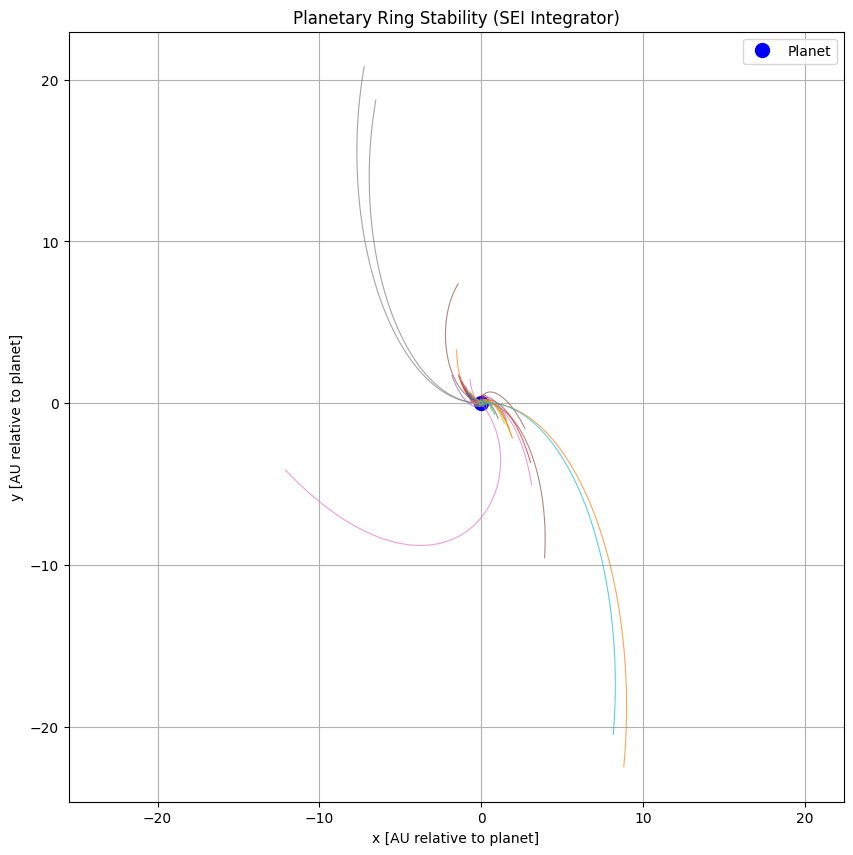

In [5]:
# Plot ring particle orbits relative to planet
plt.figure(figsize=(10,10))
plt.plot(0,0,'bo', markersize=10, label='Planet')  # Planet at origin
for j in range(len(ring_pos)):
    plt.plot(ring_pos[j][:,0], ring_pos[j][:,1], lw=0.8, alpha=0.7)
plt.xlabel('x [AU relative to planet]')
plt.ylabel('y [AU relative to planet]')
plt.title('Planetary Ring Stability (SEI Integrator)')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

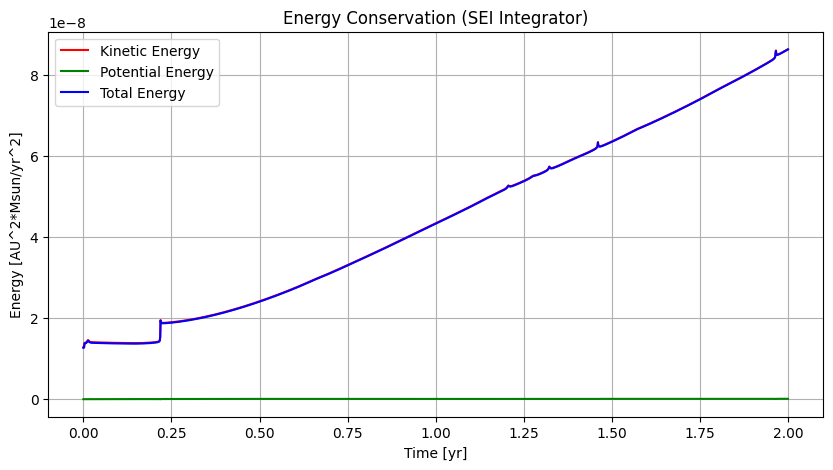

In [6]:
# Plot energy conservation
plt.figure(figsize=(10,5))
plt.plot(np.arange(len(KE))*0.001, KE, label='Kinetic Energy', color='red')
plt.plot(np.arange(len(PE))*0.001, PE, label='Potential Energy', color='green')
plt.plot(np.arange(len(TE))*0.001, TE, label='Total Energy', color='blue')
plt.xlabel('Time [yr]')
plt.ylabel('Energy [AU^2*Msun/yr^2]')
plt.title('Energy Conservation (SEI Integrator)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# Print first 10 angular momentum values
print("First 10 angular momentum values:")
print(L[:10])

First 10 angular momentum values:
[9.39917373e-10 9.39867265e-10 9.39770680e-10 9.39627092e-10
 9.39433547e-10 9.39189359e-10 9.38894466e-10 9.38548828e-10
 9.38152367e-10 9.37704972e-10]


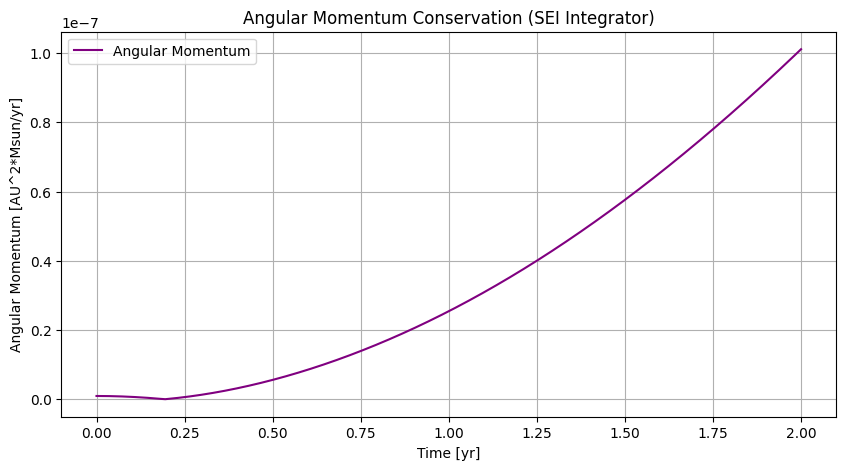

In [8]:
# Plot angular momentum conservation
plt.figure(figsize=(10,5))
plt.plot(np.arange(len(L))*0.001, L, label='Angular Momentum', color='purple')
plt.xlabel('Time [yr]')
plt.ylabel('Angular Momentum [AU^2*Msun/yr]')
plt.title('Angular Momentum Conservation (SEI Integrator)')
plt.grid(True)
plt.legend()
plt.show()

<p style="display: flex; justify-content: space-between;">
  <a href="../04-Understanding-Integrators/05-MERCURIUS-Integrator.ipynb" target="_blank">Previous</a>
  <a href="../05-Applications/01-Tidal-Effects.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-04-06.gif">